# US-JEPA Video Evaluation Notebook

**Research question:** Does the pretrained US-JEPA encoder learn stable, meaningful, and
temporally consistent representations when processing real carotid ultrasound **videos**?

This notebook:
- Loads the **already-pretrained** US-JEPA encoder checkpoint (no retraining, inference only).
- Extracts frames from carotid ultrasound video(s).
- Computes frame embeddings and analyzes their **temporal behavior**: consecutive-frame
  similarity, embedding trajectories (PCA/t-SNE/UMAP), smoothness metrics, nearest-neighbor
  retrieval, and outlier detection.
- Saves a JSON summary report plus all figures.


## 0. Setup Google Drive & Environment



In [ ]:
# Mount Google Drive (Colab only) — safe to skip if running locally
import os

IN_COLAB = "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted.")
else:
    print("Not running in Colab skipping Drive mount. Set CHECKPOINT_DIR manually below.")


Mounted at /content/drive
Google Drive mounted.


In [ ]:
# Install any missing dependencies
%pip install -q opencv-python-headless umap-learn scikit-learn matplotlib seaborn tqdm


In [ ]:
import json
import glob
import math
import random
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("umap-learn not available — UMAP trajectory plot will be skipped.")

from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


Using device: cuda


## 1. Paths & Configuration

Update these paths to match your Drive layout. `CHECKPOINT_DIR` should contain
`encoder_best.pth` and `config.json` produced by the pretraining notebook.


In [ ]:
CHECKPOINT_DIR = "/content/drive/MyDrive/checkpoints"   # folder with encoder_best.pth + config.json
VIDEO_DIR      = "/content/drive/MyDrive/US-JEPA/videos"        # folder containing .mp4 / .avi videos
OUTPUT_DIR     = "/content/drive/MyDrive/US-JEPA/video_eval_outputs"

# If not in Colab, point these at local equivalents, e.g.:
# CHECKPOINT_DIR = "./checkpoints"
# VIDEO_DIR      = "./videos"
# OUTPUT_DIR     = "./video_eval_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "encoder_best.pth")
CONFIG_PATH     = os.path.join(CHECKPOINT_DIR, "config.json")

print("Checkpoint:", CHECKPOINT_PATH, "| exists:", os.path.exists(CHECKPOINT_PATH))
print("Config:    ", CONFIG_PATH, "| exists:", os.path.exists(CONFIG_PATH))
print("Video dir: ", VIDEO_DIR, "| exists:", os.path.exists(VIDEO_DIR))


Checkpoint: /content/drive/MyDrive/checkpoints/encoder_best.pth | exists: True
Config:     /content/drive/MyDrive/checkpoints/config.json | exists: True
Video dir:  /content/drive/MyDrive/US-JEPA/videos | exists: True


In [ ]:
# Load pretraining config (patch size, image size, normalization stats, etc.)
with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

IMG_SIZE   = config.get("img_size", 224)
PATCH_SIZE = config.get("patch_size", 16)
MEAN       = config.get("norm_mean", [0.5])
STD        = config.get("norm_std", [0.5])
EMBED_DIM  = config.get("embed_dim", 384)   # ViT-S/16 default

print(json.dumps(config, indent=2)[:2000])
print(f"\nUsing IMG_SIZE={IMG_SIZE}, PATCH_SIZE={PATCH_SIZE}, EMBED_DIM={EMBED_DIM}")


{
  "data_dir": "/content/drive/MyDrive/IMAGES",
  "checkpoint_dir": "./checkpoints",
  "log_dir": "./runs/usjepa",
  "img_size": 256,
  "img_channels": 1,
  "patch_size": 16,
  "embed_dim": 384,
  "encoder_depth": 8,
  "encoder_heads": 6,
  "predictor_dim": 192,
  "predictor_depth": 4,
  "predictor_heads": 4,
  "mask_ratio": 0.4,
  "n_target_blocks": 6,
  "target_scale": [
    0.025,
    0.05
  ],
  "target_aspect": [
    0.5,
    2.0
  ],
  "ema_momentum_start": 0.996,
  "ema_momentum_end": 1.0,
  "optimizer": "adamw",
  "lr": 0.001,
  "min_lr": 1e-05,
  "weight_decay": 0.05,
  "warmup_epochs": 5,
  "epochs": 100,
  "batch_size": 32,
  "val_fraction": 0.1,
  "num_workers": 2,
  "pin_memory": true,
  "mixed_precision": true,
  "save_every": 10,
  "early_stop_patience": 20,
  "variance_loss_weight": 1.0,
  "variance_gamma": 1.0,
  "variance_eps": 0.0001,
  "min_epochs_before_stop": 30,
  "collapse_std_thresh": 0.1,
  "resume_checkpoint": null,
  "seed": 42,
  "device": "cuda",
  "min_b

## 2. Load the Pretrained Encoder (inference only)

We load **only the encoder weights** from `encoder_best.pth`. This notebook never updates
these weights — `model.eval()` + `torch.no_grad()` everywhere below.

Replace `build_encoder()` with the exact architecture-building function used in the
pretraining notebook if it differs (e.g. your functional-dict ViT-S/16 builder). The loader
below tries a few common checkpoint layouts automatically.


In [ ]:
def build_encoder():
    '''
    Rebuild the ViT-S/16 encoder architecture used for US-JEPA pretraining.
    Replace this with your project's actual functional-dict / timm builder if different.
    '''
    try:
        import timm
        model = timm.create_model(
            "vit_small_patch16_224",
            pretrained=False,
            img_size=IMG_SIZE,
            num_classes=0,   # no classification head — we want tokens
        )
        return model
    except ImportError:
        raise RuntimeError(
            "timm not installed and no custom builder provided. "
            "pip install timm, or paste your custom build_encoder() implementation here."
        )


def load_encoder_checkpoint(model, ckpt_path):
    ckpt = torch.load(ckpt_path, map_location="cpu")

    # Handle a few common checkpoint layouts
    if isinstance(ckpt, dict):
        if "encoder_state_dict" in ckpt:
            state_dict = ckpt["encoder_state_dict"]
        elif "model_state_dict" in ckpt:
            state_dict = ckpt["model_state_dict"]
        elif "state_dict" in ckpt:
            state_dict = ckpt["state_dict"]
        else:
            state_dict = ckpt  # assume it's already a bare state_dict
    else:
        state_dict = ckpt

    # Strip common prefixes (e.g. "encoder.", "module.")
    cleaned = {}
    for k, v in state_dict.items():
        nk = k
        for prefix in ("encoder.", "module.", "backbone.", "student."):
            if nk.startswith(prefix):
                nk = nk[len(prefix):]
        cleaned[nk] = v

    missing, unexpected = model.load_state_dict(cleaned, strict=False)
    print(f"Loaded checkpoint. Missing keys: {len(missing)} | Unexpected keys: {len(unexpected)}")
    if len(missing) > 0:
        print("  e.g. missing:", missing[:5])
    if len(unexpected) > 0:
        print("  e.g. unexpected:", unexpected[:5])
    return model


encoder = build_encoder()
encoder = load_encoder_checkpoint(encoder, CHECKPOINT_PATH)
encoder.eval()
encoder.to(device)

for p in encoder.parameters():
    p.requires_grad_(False)

print("Encoder ready on", device, "— all parameters frozen (inference only).")


Loaded checkpoint. Missing keys: 148 | Unexpected keys: 5
  e.g. missing: ['patch_embed.proj.weight', 'patch_embed.proj.bias', 'blocks.0.norm1.weight', 'blocks.0.norm1.bias', 'blocks.0.attn.qkv.weight']
  e.g. unexpected: ['patch_embed', 'blocks', 'norm', 'grid_size', 'n_patches']
Encoder ready on cuda — all parameters frozen (inference only).


In [ ]:
@torch.no_grad()
def get_patch_tokens(model, x):
    '''
    Returns patch tokens (CLS removed) for a batch of images x: (B, C, H, W).
    Falls back gracefully across common timm ViT APIs.
    '''
    if hasattr(model, "forward_features"):
        feats = model.forward_features(x)
        if isinstance(feats, dict):
            tokens = feats.get("x_norm_patchtokens", feats.get("last_hidden_state"))
        else:
            tokens = feats
        # timm ViT forward_features often returns (B, N+1, D) including CLS token at index 0
        if tokens.dim() == 3 and tokens.shape[1] > 1:
            tokens = tokens[:, 1:, :]  # drop CLS
        return tokens
    else:
        raise RuntimeError("Model has no forward_features — adapt get_patch_tokens() to your architecture.")


@torch.no_grad()
def embed_frames(model, x):
    '''
    x: (B, C, H, W) preprocessed batch.
    Returns L2-normalized, mean-pooled embeddings: (B, D)
    '''
    tokens = get_patch_tokens(model, x)      # (B, N, D)
    pooled = tokens.mean(dim=1)              # mean-pool patch embeddings
    pooled = F.normalize(pooled, p=2, dim=-1)  # L2 normalize
    return pooled


## 3. Phase 1: Video Loading & Frame Extraction

Loads one or multiple ultrasound videos (`.mp4` / `.avi`), extracts frames in order with
OpenCV, optionally subsamples every Nth frame, and preprocesses each frame identically to
the pretraining pipeline (resize + normalize).


In [ ]:
SAMPLE_EVERY_N = 1   # set >1 to subsample long videos, e.g. 2 = every other frame

def list_videos(video_dir):
    exts = ("*.mp4", "*.avi", "*.mov", "*.MP4", "*.AVI")
    paths = []
    for e in exts:
        paths.extend(glob.glob(os.path.join(video_dir, e)))
    return sorted(paths)


def extract_frames(video_path, sample_every_n=1):
    '''
    Extract frames from a video in order, preserving frame indices.
    Returns: list of (frame_idx, frame_bgr) tuples.
    '''
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise IOError(f"Could not open video: {video_path}")

    frames = []
    idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if idx % sample_every_n == 0:
            frames.append((idx, frame))
        idx += 1
    cap.release()
    return frames


def preprocess_frame(frame_bgr, img_size=IMG_SIZE, mean=MEAN, std=STD):
    '''
    Resize + normalize a single BGR frame exactly as done during pretraining.
    Returns a torch tensor of shape (C, H, W).
    '''
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    frame_resized = cv2.resize(frame_rgb, (img_size, img_size), interpolation=cv2.INTER_AREA)
    frame_norm = frame_resized.astype(np.float32) / 255.0

    mean_arr = np.array(mean, dtype=np.float32)
    std_arr = np.array(std, dtype=np.float32)
    if mean_arr.size == 1:
        mean_arr = np.repeat(mean_arr, 3)
        std_arr = np.repeat(std_arr, 3)

    frame_norm = (frame_norm - mean_arr) / std_arr
    tensor = torch.from_numpy(frame_norm).permute(2, 0, 1).float()  # (C, H, W)
    return tensor


video_paths = list_videos(VIDEO_DIR)
print(f"Found {len(video_paths)} video(s) in {VIDEO_DIR}:")
for v in video_paths:
    print(" -", v)


Found 2 video(s) in /content/drive/MyDrive/US-JEPA/videos:
 - /content/drive/MyDrive/US-JEPA/videos/13_0001.AVI
 - /content/drive/MyDrive/US-JEPA/videos/6_0009.AVI


## 4. Phase 2: Frame Embedding Extraction

Processes frames in batches through the frozen encoder, storing frame indices and their
corresponding embedding vectors. Designed to scale to long videos without holding every
frame in memory simultaneously (frames are decoded, embedded, and released batch by batch).


In [ ]:
class FrameDataset(Dataset):
    def __init__(self, indexed_frames, img_size=IMG_SIZE, mean=MEAN, std=STD):
        self.indexed_frames = indexed_frames
        self.img_size = img_size
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.indexed_frames)

    def __getitem__(self, i):
        idx, frame = self.indexed_frames[i]
        tensor = preprocess_frame(frame, self.img_size, self.mean, self.std)
        return idx, tensor


@torch.no_grad()
def extract_video_embeddings(video_path, batch_size=32, sample_every_n=SAMPLE_EVERY_N, num_workers=2):
    indexed_frames = extract_frames(video_path, sample_every_n=sample_every_n)
    ds = FrameDataset(indexed_frames)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    all_indices = []
    all_embeddings = []

    for idxs, batch in tqdm(dl, desc=f"Embedding {os.path.basename(video_path)}"):
        batch = batch.to(device)
        emb = embed_frames(encoder, batch)          # (B, D), L2-normalized
        all_indices.extend(idxs.tolist())
        all_embeddings.append(emb.cpu().numpy())

    all_embeddings = np.concatenate(all_embeddings, axis=0)
    order = np.argsort(all_indices)
    all_indices = np.array(all_indices)[order]
    all_embeddings = all_embeddings[order]

    # Also keep raw frames (RGB, small) for later visualization (queries/outliers/neighbors)
    raw_frames = {idx: cv2.cvtColor(f, cv2.COLOR_BGR2RGB) for idx, f in indexed_frames}

    return all_indices, all_embeddings, raw_frames


if len(video_paths) == 0:
    raise FileNotFoundError(
        f"No videos found in {VIDEO_DIR}. Add a .mp4/.avi file and re-run this cell."
    )

# Analyze the first video by default — loop over video_paths for a batch analysis
VIDEO_PATH = video_paths[0]
print("Analyzing:", VIDEO_PATH)

frame_indices, embeddings, raw_frames = extract_video_embeddings(VIDEO_PATH)
print("Frames processed:", len(frame_indices))
print("Embeddings shape:", embeddings.shape)


Analyzing: /content/drive/MyDrive/US-JEPA/videos/13_0001.AVI


Embedding 13_0001.AVI:   0%|          | 0/4 [00:00<?, ?it/s]

Frames processed: 122
Embeddings shape: (122, 384)


## 5. Phase 3 Temporal Embedding Evaluation

### 5.1 Consecutive-frame cosine similarity
Nearby frames should have high similarity; sudden drops may indicate probe movement or a
change in anatomy.


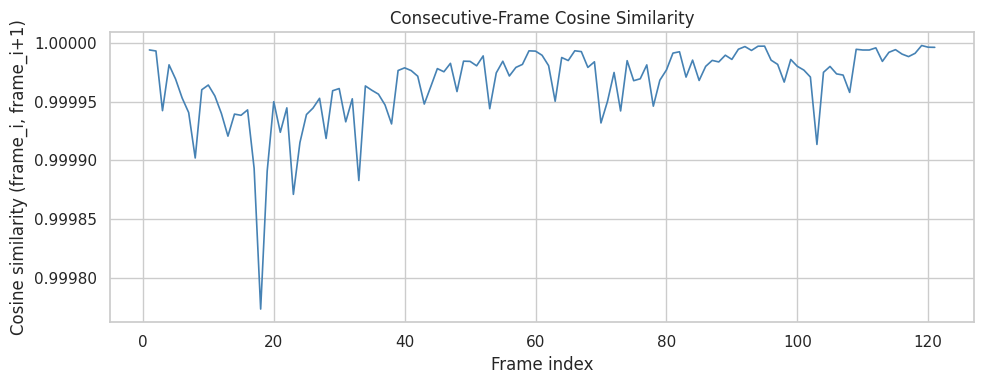

Mean cosine similarity: 1.0000 | Std: 0.0000 | Min: 0.9998


In [ ]:
def consecutive_cosine_similarity(embeddings):
    sims = np.array([
        np.dot(embeddings[i], embeddings[i + 1])   # already L2-normalized -> dot = cosine
        for i in range(len(embeddings) - 1)
    ])
    return sims

cos_sims = consecutive_cosine_similarity(embeddings)

plt.figure(figsize=(10, 4))
plt.plot(frame_indices[1:], cos_sims, color="steelblue", linewidth=1.2)
plt.xlabel("Frame index")
plt.ylabel("Cosine similarity (frame_i, frame_i+1)")
plt.title("Consecutive-Frame Cosine Similarity")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "frame_similarity_plot.png"), dpi=150)
plt.show()

print(f"Mean cosine similarity: {cos_sims.mean():.4f} | Std: {cos_sims.std():.4f} | Min: {cos_sims.min():.4f}")


### 5.2 Embedding L2 distance over time

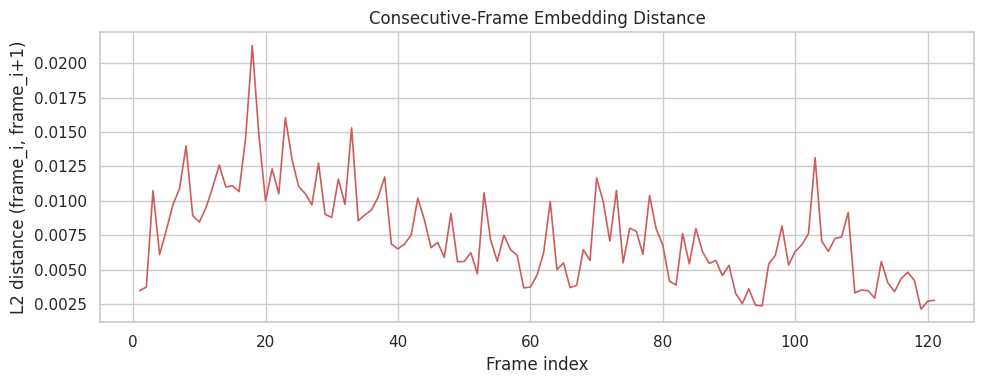

Mean L2 distance: 0.0076 | Std: 0.0034 | Max: 0.0213


In [ ]:
def consecutive_l2_distance(embeddings):
    dists = np.array([
        np.linalg.norm(embeddings[i] - embeddings[i + 1])
        for i in range(len(embeddings) - 1)
    ])
    return dists

l2_dists = consecutive_l2_distance(embeddings)

plt.figure(figsize=(10, 4))
plt.plot(frame_indices[1:], l2_dists, color="indianred", linewidth=1.2)
plt.xlabel("Frame index")
plt.ylabel("L2 distance (frame_i, frame_i+1)")
plt.title("Consecutive-Frame Embedding Distance")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "embedding_distance_plot.png"), dpi=150)
plt.show()

print(f"Mean L2 distance: {l2_dists.mean():.4f} | Std: {l2_dists.std():.4f} | Max: {l2_dists.max():.4f}")


### 5.3 Embedding trajectory visualization (PCA / t-SNE / UMAP)

Projects all frame embeddings to 2D and connects consecutive frames with lines to reveal
the temporal path traced through embedding space.


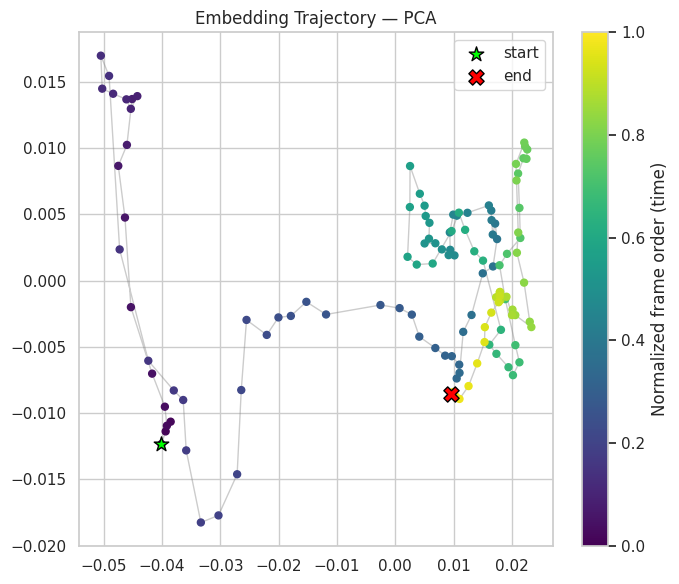

PCA explained variance ratio: [0.7024398  0.06137273]


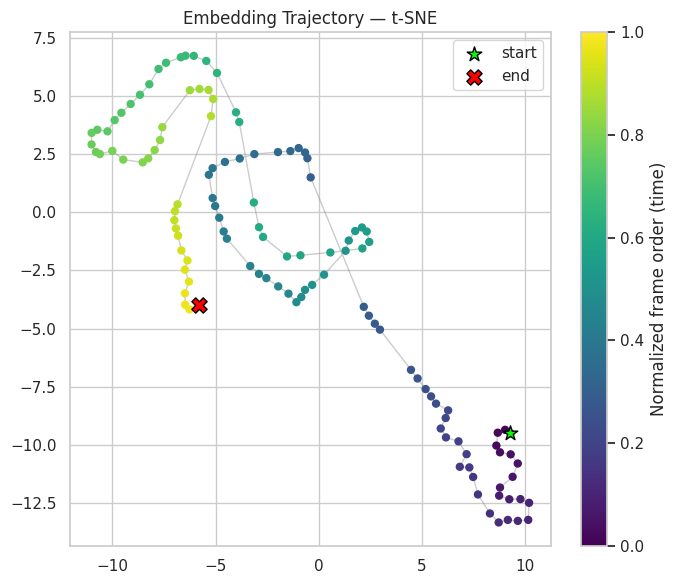

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


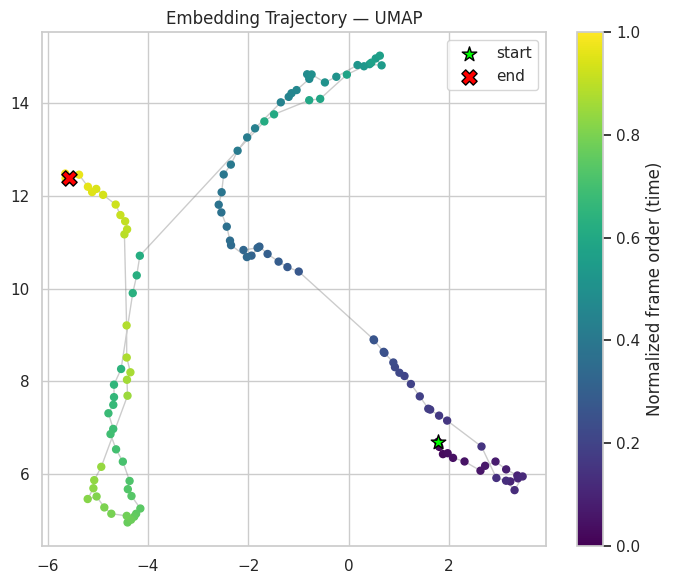

In [ ]:
def plot_trajectory(coords, title, save_path, cmap="viridis"):
    plt.figure(figsize=(7, 6))
    n = len(coords)
    colors = np.linspace(0, 1, n)

    # Connect consecutive frames with lines to show temporal path
    plt.plot(coords[:, 0], coords[:, 1], color="gray", alpha=0.4, linewidth=1, zorder=1)
    sc = plt.scatter(coords[:, 0], coords[:, 1], c=colors, cmap=cmap, s=25, zorder=2)
    plt.scatter(coords[0, 0], coords[0, 1], c="lime", s=120, marker="*", label="start", zorder=3, edgecolors="black")
    plt.scatter(coords[-1, 0], coords[-1, 1], c="red", s=120, marker="X", label="end", zorder=3, edgecolors="black")

    cbar = plt.colorbar(sc)
    cbar.set_label("Normalized frame order (time)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


# --- PCA ---
pca = PCA(n_components=2, random_state=SEED)
pca_coords = pca.fit_transform(embeddings)
plot_trajectory(pca_coords, "Embedding Trajectory — PCA",
                 os.path.join(OUTPUT_DIR, "embedding_trajectory_pca.png"))
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")

# --- t-SNE ---
perplexity = max(5, min(30, len(embeddings) // 4))
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=SEED, init="pca")
tsne_coords = tsne.fit_transform(embeddings)
plot_trajectory(tsne_coords, "Embedding Trajectory — t-SNE",
                 os.path.join(OUTPUT_DIR, "embedding_trajectory_tsne.png"))

# --- UMAP (optional) ---
if HAS_UMAP:
    reducer = umap.UMAP(n_components=2, random_state=SEED)
    umap_coords = reducer.fit_transform(embeddings)
    plot_trajectory(umap_coords, "Embedding Trajectory — UMAP",
                     os.path.join(OUTPUT_DIR, "embedding_trajectory_umap.png"))
else:
    umap_coords = None
    print("Skipping UMAP trajectory (umap-learn not installed).")


### 5.4 Temporal smoothness metrics

In [ ]:
def embedding_velocity(embeddings):
    '''Frame-to-frame L2 velocity — same as consecutive L2 distance, kept explicit for clarity.'''
    return consecutive_l2_distance(embeddings)

velocity = embedding_velocity(embeddings)

smoothness_stats = {
    "avg_cosine_similarity": float(cos_sims.mean()),
    "std_cosine_similarity": float(cos_sims.std()),
    "avg_l2_distance": float(l2_dists.mean()),
    "std_l2_distance": float(l2_dists.std()),
    "avg_embedding_velocity": float(velocity.mean()),
    "max_embedding_velocity": float(velocity.max()),
}

print(json.dumps(smoothness_stats, indent=2))


{
  "avg_cosine_similarity": 0.999965488910675,
  "std_cosine_similarity": 3.173686491209082e-05,
  "avg_l2_distance": 0.007572572212666273,
  "std_l2_distance": 0.0033822213299572468,
  "avg_embedding_velocity": 0.007572572212666273,
  "max_embedding_velocity": 0.021269597113132477
}


### 5.5 Nearest-neighbor retrieval

Randomly sample a few query frames and retrieve their top-5 nearest neighbors by cosine
similarity, to check whether visually similar anatomy yields similar embeddings.


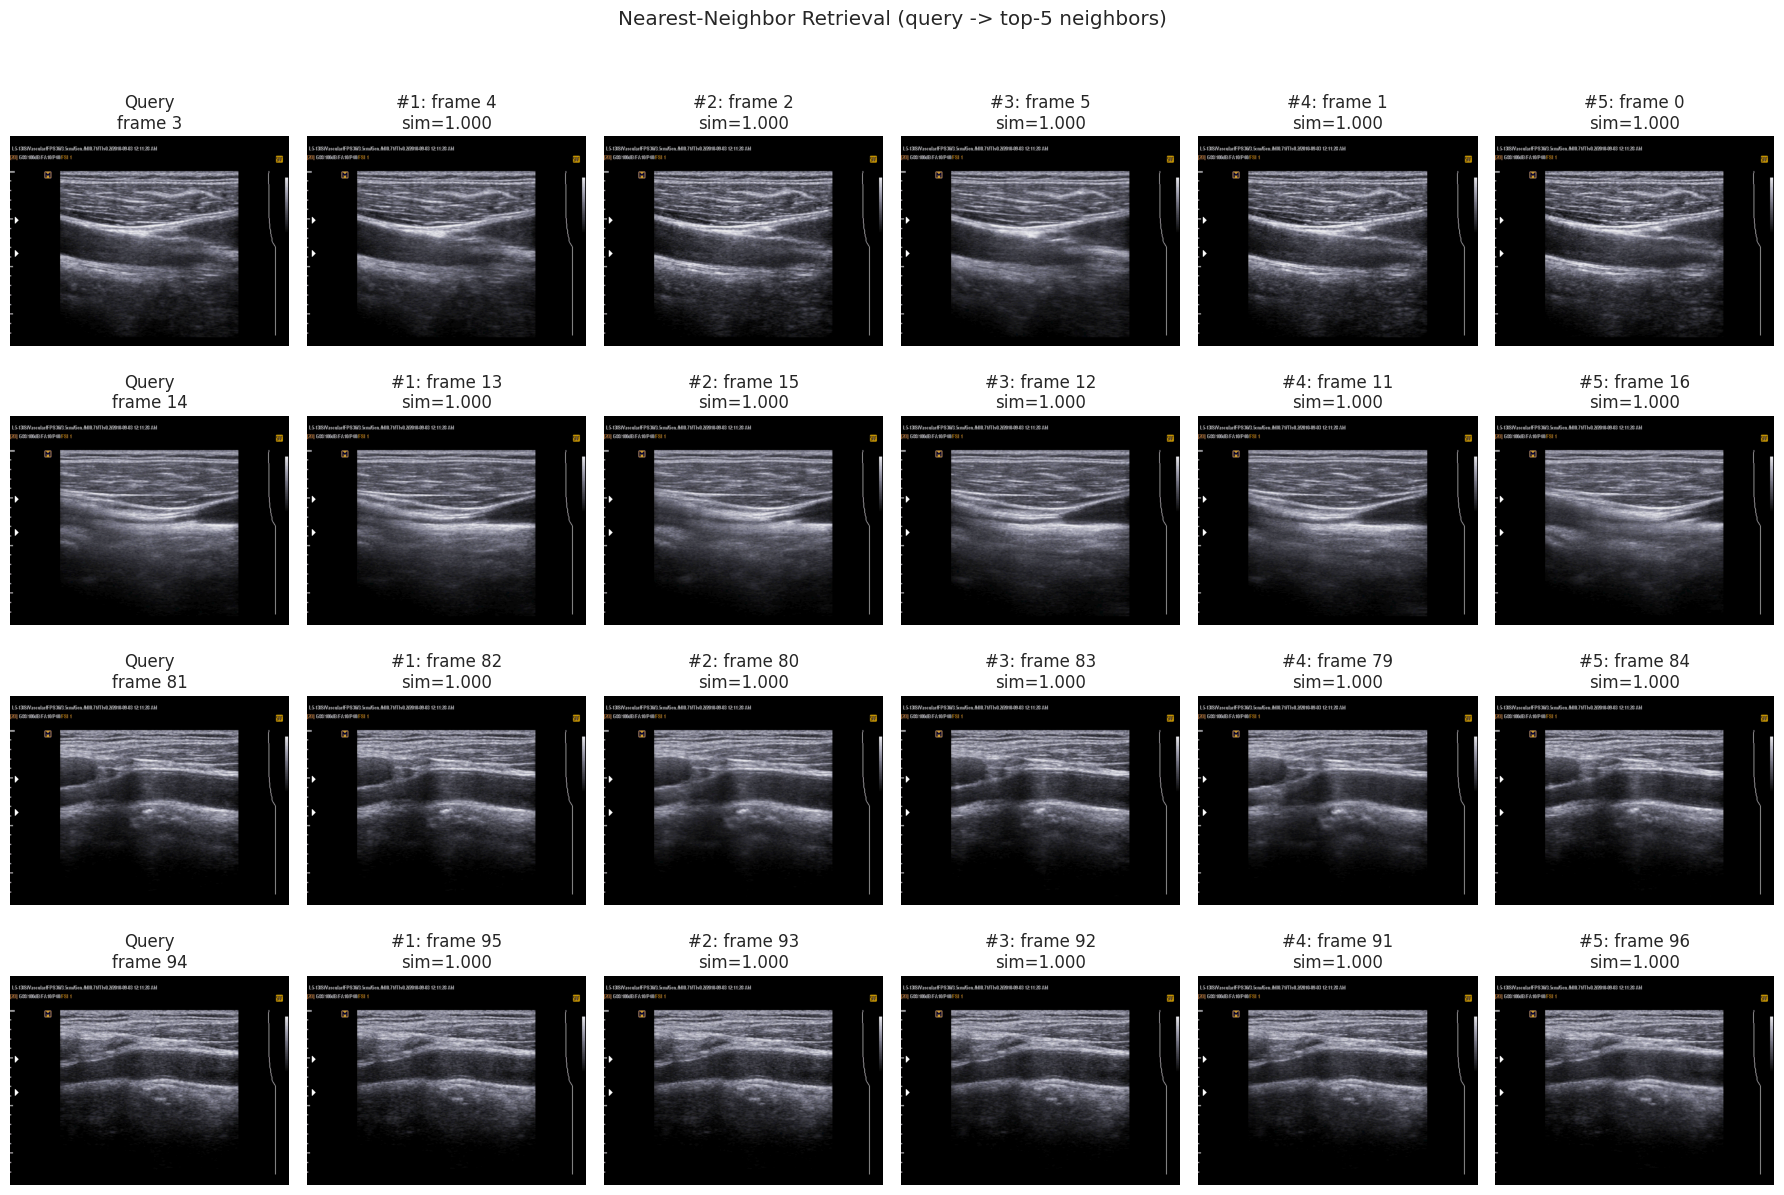

In [ ]:
def retrieve_nearest_neighbors(embeddings, query_idx, k=5):
    sims = cosine_similarity(embeddings[query_idx:query_idx + 1], embeddings)[0]
    order = np.argsort(-sims)
    order = order[order != query_idx]   # exclude the query itself
    return order[:k], sims[order[:k]]


n_queries = min(4, len(embeddings))
query_positions = sorted(random.sample(range(len(embeddings)), n_queries))

fig, axes = plt.subplots(n_queries, 6, figsize=(18, 3 * n_queries))
if n_queries == 1:
    axes = axes[None, :]

for row, qpos in enumerate(query_positions):
    q_frame_idx = frame_indices[qpos]
    neighbor_positions, neighbor_sims = retrieve_nearest_neighbors(embeddings, qpos, k=5)

    axes[row, 0].imshow(raw_frames[q_frame_idx])
    axes[row, 0].set_title(f"Query\nframe {q_frame_idx}")
    axes[row, 0].axis("off")

    for col, (npos, sim) in enumerate(zip(neighbor_positions, neighbor_sims), start=1):
        n_frame_idx = frame_indices[npos]
        axes[row, col].imshow(raw_frames[n_frame_idx])
        axes[row, col].set_title(f"#{col}: frame {n_frame_idx}\nsim={sim:.3f}")
        axes[row, col].axis("off")

plt.suptitle("Nearest-Neighbor Retrieval (query -> top-5 neighbors)", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "nearest_neighbor_frames.png"), dpi=150, bbox_inches="tight")
plt.show()


### 5.6 Outlier detection

Flags frames whose embeddings differ strongly from their temporal neighbors — often caused
by probe movement, artifacts, anatomy changes, or poor image quality.


Detected 3 outlier frame(s) (z > 2.0): [17, 18, 23]


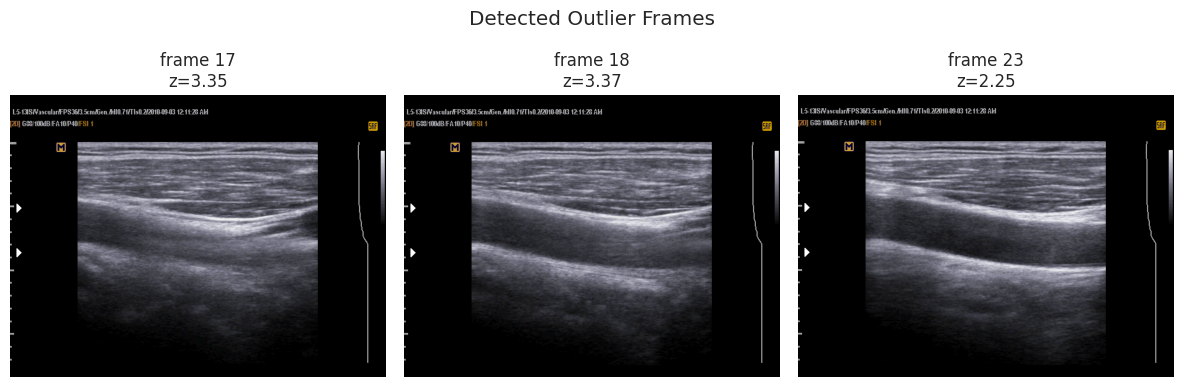

In [ ]:
def detect_outliers(embeddings, z_thresh=2.0):
    '''
    A frame is an outlier if its average distance to its immediate neighbors (i-1, i+1)
    is unusually large relative to the rest of the video (z-score based).
    '''
    n = len(embeddings)
    local_dist = np.zeros(n)
    for i in range(n):
        neighbors = []
        if i > 0:
            neighbors.append(np.linalg.norm(embeddings[i] - embeddings[i - 1]))
        if i < n - 1:
            neighbors.append(np.linalg.norm(embeddings[i] - embeddings[i + 1]))
        local_dist[i] = np.mean(neighbors)

    z = (local_dist - local_dist.mean()) / (local_dist.std() + 1e-8)
    outlier_positions = np.where(z > z_thresh)[0]
    return outlier_positions, local_dist, z


outlier_positions, local_dist, z_scores = detect_outliers(embeddings, z_thresh=2.0)
outlier_frame_indices = frame_indices[outlier_positions]
print(f"Detected {len(outlier_positions)} outlier frame(s) (z > 2.0): {outlier_frame_indices.tolist()}")

if len(outlier_positions) > 0:
    n_show = min(len(outlier_positions), 8)
    cols = min(4, n_show)
    rows = math.ceil(n_show / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for i in range(n_show):
        pos = outlier_positions[i]
        fidx = frame_indices[pos]
        axes[i].imshow(raw_frames[fidx])
        axes[i].set_title(f"frame {fidx}\nz={z_scores[pos]:.2f}")
        axes[i].axis("off")
    for j in range(n_show, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Detected Outlier Frames", y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "outlier_frames.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No outlier frames detected at this threshold.")


## 6. Phase 4: Embedding Statistics

Same statistics computed in the still-image evaluation notebook, so results are directly
comparable: variance, covariance, pairwise similarity, norms, and effective rank.


{
  "mean_variance_per_dim": 2.1402299807959935e-06,
  "min_variance_per_dim": 2.677691952612804e-07,
  "mean_pairwise_cosine_similarity": 0.9991714358329773,
  "mean_embedding_norm": 1.0,
  "std_embedding_norm": 4.3170807373371645e-08,
  "effective_rank": 37.05458068847656,
  "embedding_dim": 384
}


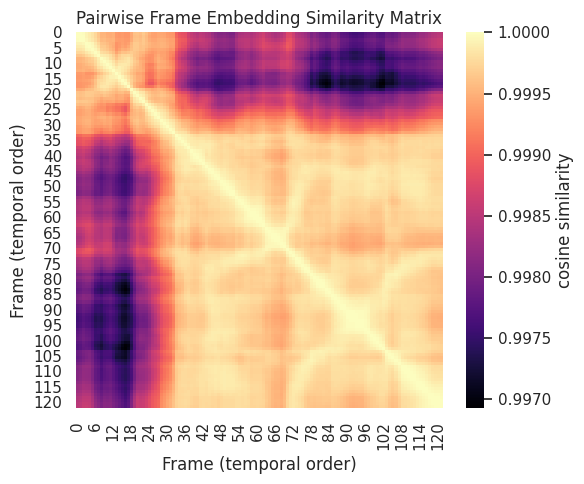

In [ ]:
def embedding_statistics(embeddings):
    var_per_dim = embeddings.var(axis=0)
    cov = np.cov(embeddings, rowvar=False)
    pairwise_sim = cosine_similarity(embeddings)
    norms = np.linalg.norm(embeddings, axis=1)

    # Effective rank via normalized singular value entropy
    _, s, _ = np.linalg.svd(embeddings - embeddings.mean(axis=0), full_matrices=False)
    p = s / (s.sum() + 1e-12)
    entropy = -np.sum(p * np.log(p + 1e-12))
    effective_rank = float(np.exp(entropy))

    stats = {
        "mean_variance_per_dim": float(var_per_dim.mean()),
        "min_variance_per_dim": float(var_per_dim.min()),
        "mean_pairwise_cosine_similarity": float(pairwise_sim[np.triu_indices_from(pairwise_sim, k=1)].mean()),
        "mean_embedding_norm": float(norms.mean()),
        "std_embedding_norm": float(norms.std()),
        "effective_rank": effective_rank,
        "embedding_dim": int(embeddings.shape[1]),
    }
    return stats, cov, pairwise_sim


video_stats, cov_matrix, pairwise_sim_matrix = embedding_statistics(embeddings)
print(json.dumps(video_stats, indent=2))

plt.figure(figsize=(6, 5))
sns.heatmap(pairwise_sim_matrix, cmap="magma", cbar_kws={"label": "cosine similarity"})
plt.title("Pairwise Frame Embedding Similarity Matrix")
plt.xlabel("Frame (temporal order)")
plt.ylabel("Frame (temporal order)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pairwise_similarity_matrix.png"), dpi=150)
plt.show()


> **Note:** to directly compare against the still-image evaluation notebook's collapse
> analysis, load that notebook's saved statistics (e.g. a `image_eval_stats.json`) and diff
> the `mean_variance_per_dim` / `effective_rank` values against `video_stats` above.


In [ ]:
IMAGE_EVAL_STATS_PATH = os.path.join(CHECKPOINT_DIR, "image_eval_stats.json")  # optional, edit if named differently

if os.path.exists(IMAGE_EVAL_STATS_PATH):
    with open(IMAGE_EVAL_STATS_PATH, "r") as f:
        image_stats = json.load(f)
    comparison = {
        "metric": [],
        "image_eval": [],
        "video_eval": [],
    }
    for k in video_stats:
        if k in image_stats:
            comparison["metric"].append(k)
            comparison["image_eval"].append(image_stats[k])
            comparison["video_eval"].append(video_stats[k])
    for m, im, vi in zip(comparison["metric"], comparison["image_eval"], comparison["video_eval"]):
        print(f"{m:35s} | image={im:.4f} | video={vi:.4f}")
else:
    print(f"No image-eval stats found at {IMAGE_EVAL_STATS_PATH} — skipping direct comparison.")
    image_stats = None


No image-eval stats found at /content/drive/MyDrive/checkpoints/image_eval_stats.json — skipping direct comparison.


## 7. Phase 5: Video Summary Report

Aggregates everything above into a single JSON report.


In [ ]:
video_report = {
    "video_path": VIDEO_PATH,
    "num_frames_processed": int(len(frame_indices)),
    "sample_every_n": SAMPLE_EVERY_N,
    "temporal_smoothness": smoothness_stats,
    "embedding_statistics": video_stats,
    "num_outlier_frames": int(len(outlier_positions)),
    "outlier_frame_indices": outlier_frame_indices.tolist(),
    "config_used": {
        "img_size": IMG_SIZE,
        "patch_size": PATCH_SIZE,
        "embed_dim": EMBED_DIM,
    },
}

report_path = os.path.join(OUTPUT_DIR, "video_embedding_report.json")
with open(report_path, "w") as f:
    json.dump(video_report, f, indent=2)

print("Saved report to:", report_path)
print(json.dumps(video_report, indent=2))


Saved report to: /content/drive/MyDrive/US-JEPA/video_eval_outputs/video_embedding_report.json
{
  "video_path": "/content/drive/MyDrive/US-JEPA/videos/13_0001.AVI",
  "num_frames_processed": 122,
  "sample_every_n": 1,
  "temporal_smoothness": {
    "avg_cosine_similarity": 0.999965488910675,
    "std_cosine_similarity": 3.173686491209082e-05,
    "avg_l2_distance": 0.007572572212666273,
    "std_l2_distance": 0.0033822213299572468,
    "avg_embedding_velocity": 0.007572572212666273,
    "max_embedding_velocity": 0.021269597113132477
  },
  "embedding_statistics": {
    "mean_variance_per_dim": 2.1402299807959935e-06,
    "min_variance_per_dim": 2.677691952612804e-07,
    "mean_pairwise_cosine_similarity": 0.9991714358329773,
    "mean_embedding_norm": 1.0,
    "std_embedding_norm": 4.3170807373371645e-08,
    "effective_rank": 37.05458068847656,
    "embedding_dim": 384
  },
  "num_outlier_frames": 3,
  "outlier_frame_indices": [
    17,
    18,
    23
  ],
  "config_used": {
    "im